<a href="https://colab.research.google.com/github/Bishwa3901/Finance-AI-Quant-Journey/blob/main/Quant_Journey_Day_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd

stocks = ["RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS"]

data = yf.download(stocks, start="2018-01-01")['Close']

data.head()

/tmp/ipykernel_2444/3099263579.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2018-01-01")['Close']
[*********************100%***********************]  4 of 4 completed


Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,
2018-01-01,432.688995,415.244171,401.864807,1083.771362
2018-01-02,436.853760,413.697449,402.483276,1077.872437
2018-01-03,432.257355,410.322601,404.095520,1080.924561
2018-01-04,433.948975,407.952240,406.525055,1088.482666
2018-01-05,434.812195,406.586182,407.828156,1101.632080


In [3]:
#Calculating Returns
returns = data.pct_change()

returns.head()

Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,
2018-01-01,NaN,NaN,NaN,NaN
2018-01-02,0.009625,-0.003725,0.001539,-0.005443
2018-01-03,-0.010522,-0.008158,0.004006,0.002832
2018-01-04,0.003913,-0.005777,0.006012,0.006992
2018-01-05,0.001989,-0.003349,0.003205,0.012080


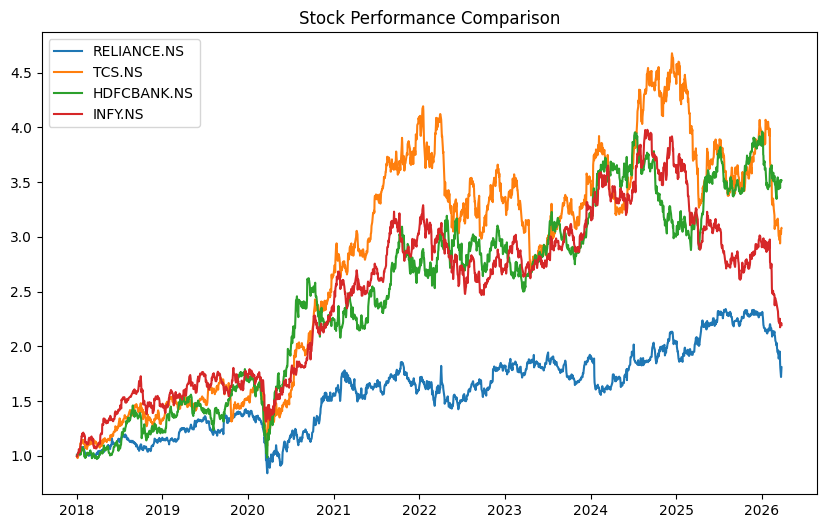

In [4]:
#comparing the stocks
import matplotlib.pyplot as plt

cumulative = (1 + returns).cumprod()

plt.figure(figsize=(10,6))
plt.plot(cumulative)
plt.legend(stocks)
plt.title("Stock Performance Comparison")
plt.show()

In [5]:
#Risk Measurements
volatility = returns.std() * (252**0.5)   #There are approx 252 market days in a year

volatility

,0
Ticker,
HDFCBANK.NS,0.240585
INFY.NS,0.271910
RELIANCE.NS,0.277815
TCS.NS,0.240731


In [6]:
expected_return = returns.mean() * 252

expected_return

,0
Ticker,
HDFCBANK.NS,0.102399
INFY.NS,0.176626
RELIANCE.NS,0.194367
TCS.NS,0.126342


Portfolio Creation

In [7]:
weights = [0.1,0.1,0.5,0.3]

In [8]:
import numpy as np

portfolio_return = np.sum(weights * expected_return)
portfolio_return

np.float64(0.16298829868091777)

In [9]:
cov_matrix = returns.cov() * 252

portfolio_volatility = np.sqrt(np.dot(weights, np.dot(cov_matrix, weights)))

portfolio_volatility

np.float64(0.20151802468629137)

In [10]:
#Assume risk-free rate = 6%.
#Sharpe= (Return−RiskFree) / Volatility
#Higher Sharpe ratio = better portfolio.

risk_free = 0.06

sharpe = (portfolio_return - risk_free)/portfolio_volatility

sharpe

np.float64(0.5110624662049088)